<a href="https://colab.research.google.com/github/nbetini99/loan-distribution-ai-model/blob/main/Loan_Approval_Lending_Club_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lending Club Loan Approval System

## Business Background

Lending Club is a peer-to-peer lending company where individuals can borrow loans, and investors can fund those loans. Lending Club was founded in 2006 by Renaud Laplanche as a peer-to-peer (P2P) lending platform in San Francisco. It was one of the pioneers in the online lending space, where individual borrowers could obtain loans, and individual or institutional investors could invest in these loans to earn interest. The platform allowed for a more direct connection between lenders and borrowers, bypassing traditional banking intermediaries.

Read more here https://en.wikipedia.org/wiki/LendingClub

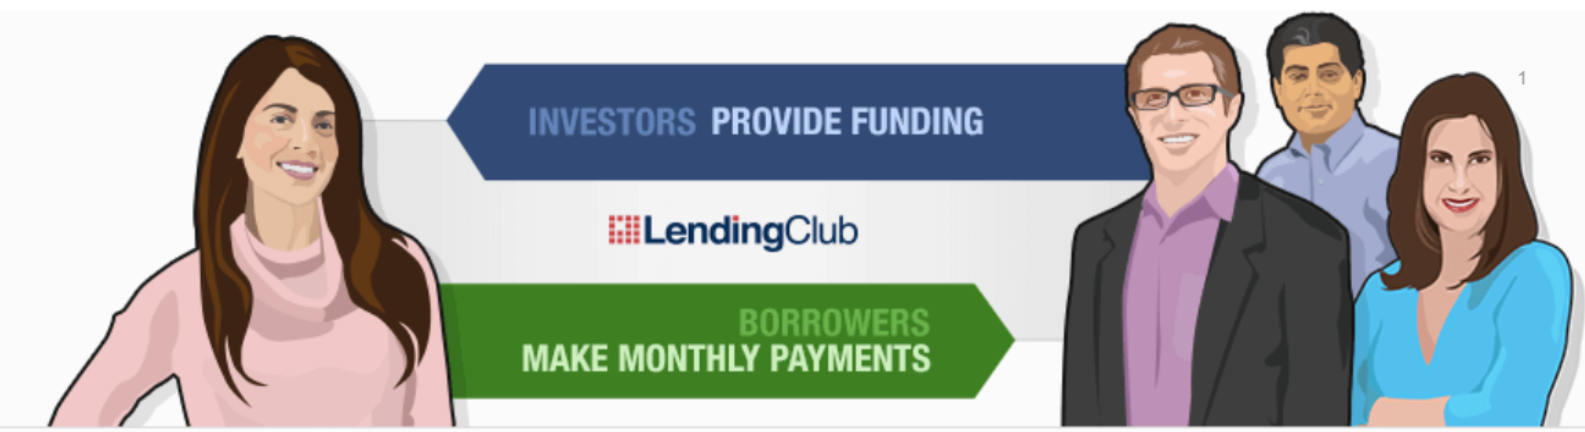

## Problem Statement

Now, whenever *Lending Club* approves a loan, there are two ways in which it is at risk:
- If LC approves a loan and the borrower fails to repay it on time
- If LC rejects a loan despite the borrower being capable of repaying the loan

Defaulting on loans can lead to significant financial losses for both the platform and investors. Similarly, not providing loans to credit-worthy customers can lead to missing out on potential revenue and profits. Therefore, a robust loan approval system is the need of the hour.

In the current loan approval process, underwriters evaluate loan applications by manually reviewing credit scores, income, debt, etc. and then, based on several parameters, either approve or reject a loan. This process is time-consuming and prone to errors.

Hence, Lending Club wants to build a loan approval system using Machine Learning models to automatically assess whether a given loan is likely to be repaid or whether the borrower is likely to default.

This is where you come in! As a budding data scientist, your goal is to help out Lending Club in creating this ML model that helps them predict whether a loan is likely to default or not.

## Data Understanding

You have been provided with around 38k loan application data from the Lending Club's website. The different columns and their description are mentioned below:

| Column Name         | Description                                                                                                                                                    |
|---------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------|
| id                  | A unique LC assigned ID for the loan listing. *(Integer)*                                                                                                       |
| member_id           | A unique LC assigned ID for the borrower member. *(Integer)*                                                                                                    |
| loan_amnt           | The listed amount of the loan applied for by the borrower. If at some point the credit department reduces the loan amount, it will be reflected in this value. *(Float)* |
| term                | The number of payments on the loan. Values are in months and can be either 36 or 60. *(Integer)*                                                                 |
| int_rate            | Interest rate on the loan. *(Float)*                                                                                                                            |
| installment         | The monthly payment owed by the borrower if the loan originates. *(Float)*                                                                                       |
| grade               | LC assigned loan grade. *(Categorical/String)*                                                                                                                  |
| sub_grade           | LC assigned loan subgrade. *(Categorical/String)*                                                                                                               |
| emp_length          | Employment length in years. Possible values are between 0 and 10, where 0 means less than one year and 10 means ten or more years. *(Integer)*                   |
| home_ownership      | The home ownership status provided by the borrower during registration. Values are: RENT, OWN, MORTGAGE, OTHER. *(Categorical/String)*                           |
| annual_inc          | The self-reported annual income provided by the borrower during registration. *(Float)*                                                                         |
| verification_status | Indicates if income was verified by LC, not verified, or if the income source was verified. *(Categorical/String)*                                               |
| purpose             | A category provided by the borrower for the loan request. *(Categorical/String)*                                                                                |
| dti                 | A ratio calculated using the borrower’s total monthly debt payments (excluding mortgage and the requested LC loan), divided by the borrower’s self-reported income. *(Float)* |
| delinq_2yrs         | The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years. *(Integer)*                                         |
| inq_last_6mths      | The number of inquiries in the past 6 months (excluding auto and mortgage inquiries). *(Integer)*                                                                |
| open_acc            | The number of open credit lines in the borrower's credit file. *(Integer)*                                                                                       |
| pub_rec             | Number of derogatory public records. *(Integer)*                                                                                                                |
| revol_bal           | Total credit revolving balance. *(Float)*                                                                                                                       |
| revol_util          | Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit. *(Float)*                             |
| total_acc           | The total number of credit lines currently in the borrower's credit file. *(Integer)*                                                                            |
| last_pymnt_amnt     | Last total payment amount received. *(Float)*                                                                                                                   |
| loan_status         | Current status of the loan. *(Categorical/String)*                                                                 
                  |

...

## Starter Code

### Necessary Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

In [10]:
pd.set_option('display.max_columns', None)
import warnings
# Suppress all warnings
warnings.filterwarnings('ignore')

### Data Loading

In [12]:
## Load the dataset
df = pd.read_csv('/content/loans.csv')




In [13]:
## Observe the first few rows
## Do you observe any issues?
df.head()


,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_amnt,loan_status
0,1077501,1296599.0,5000.0,36 months,10.65%,162.87,B,B2,10+ years,RENT,24000.0,Verified,credit_card,27.65,0.0,1.0,3.0,0.0,13648.0,83.7%,9.0,171.62,Fully Paid
1,1077430,1314167.0,2500.0,60 months,15.27%,59.83,C,C4,< 1 year,RENT,30000.0,Source Verified,car,1.00,0.0,5.0,3.0,0.0,1687.0,9.4%,4.0,119.66,Charged Off
2,1077175,1313524.0,2400.0,36 months,15.96%,84.33,C,C5,10+ years,RENT,12252.0,Not Verified,small_business,8.72,0.0,2.0,2.0,0.0,2956.0,98.5%,10.0,649.91,Fully Paid
3,1076863,1277178.0,10000.0,36 months,13.49%,339.31,C,C1,10+ years,RENT,49200.0,Source Verified,other,20.00,0.0,1.0,10.0,0.0,5598.0,21%,37.0,357.48,Fully Paid
4,1075269,1311441.0,5000.0,36 months,7.90%,156.46,A,A4,3 years,RENT,36000.0,Source Verified,wedding,11.20,0.0,3.0,9.0,0.0,7963.0,28.3%,12.0,161.03,Fully Paid


In [14]:
## Check the dataframe structure - datatypes and number of non-null rows
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38770 entries, 0 to 38769
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   38770 non-null  int64  
 1   member_id            38770 non-null  float64
 2   loan_amnt            38770 non-null  float64
 3   term                 38770 non-null  object 
 4   int_rate             38770 non-null  object 
 5   installment          38770 non-null  float64
 6   grade                38770 non-null  object 
 7   sub_grade            38770 non-null  object 
 8   emp_length           37734 non-null  object 
 9   home_ownership       38770 non-null  object 
 10  annual_inc           38770 non-null  float64
 11  verification_status  38770 non-null  object 
 12  purpose              38770 non-null  object 
 13  dti                  38770 non-null  float64
 14  delinq_2yrs          38770 non-null  float64
 15  inq_last_6mths       38770 non-null 

In [16]:
## Check the shape
print("\nShape of the dataset:", df.shape)



Shape of the dataset: (38770, 23)


In [17]:
## Check the missing values across the columns
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
id                        0
member_id                 0
loan_amnt                 0
term                      0
int_rate                  0
installment               0
grade                     0
sub_grade                 0
emp_length             1036
home_ownership            0
annual_inc                0
verification_status       0
purpose                   0
dti                       0
delinq_2yrs               0
inq_last_6mths            0
open_acc                  0
pub_rec                   0
revol_bal                 0
revol_util               50
total_acc                 0
last_pymnt_amnt           0
loan_status               0
dtype: int64


#### Observations

- Document your observations
- There are 38788 records
- There are 23 columns or features
- There are 1036 missing emp_length entries
- There are 50 missing revol_util entries
- Data types include int, float and object types
- Memory size is about 6.8 MB



### Data Cleaning

- Perform missing value treatment
- Remove extra symbols, characters, etc. from appropriate columns

In [21]:
##Dropping the unnecessary columns
##Columns which are not required for analysis - id, member_id
##Columns which are not available at the time of loan approval (Check the data dictionary and problem statement to understand this more) - installment and last_pymnt_amnt
cols_to_drop = ['id', 'member_id', 'installment', 'last_pymnt_amnt']
df.drop(columns=cols_to_drop, inplace=True)

KeyError: "['id', 'member_id', 'installment', 'last_pymnt_amnt'] not found in axis"

In [20]:
## Write your code
## Fill the missing values (replacing with median or mode)
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

In [22]:
## Check the dataframe again
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38770 entries, 0 to 38769
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            38770 non-null  float64
 1   term                 38770 non-null  object 
 2   int_rate             38770 non-null  object 
 3   grade                38770 non-null  object 
 4   sub_grade            38770 non-null  object 
 5   emp_length           38770 non-null  object 
 6   home_ownership       38770 non-null  object 
 7   annual_inc           38770 non-null  float64
 8   verification_status  38770 non-null  object 
 9   purpose              38770 non-null  object 
 10  dti                  38770 non-null  float64
 11  delinq_2yrs          38770 non-null  float64
 12  inq_last_6mths       38770 non-null  float64
 13  open_acc             38770 non-null  float64
 14  pub_rec              38770 non-null  float64
 15  revol_bal            38770 non-null 

Perform any additional data preparation steps if needed

In [24]:
## Write the code
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38770 entries, 0 to 38769
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            38770 non-null  float64
 1   term                 38770 non-null  int64  
 2   int_rate             38770 non-null  int64  
 3   grade                38770 non-null  int64  
 4   sub_grade            38770 non-null  int64  
 5   emp_length           38770 non-null  int64  
 6   home_ownership       38770 non-null  int64  
 7   annual_inc           38770 non-null  float64
 8   verification_status  38770 non-null  int64  
 9   purpose              38770 non-null  int64  
 10  dti                  38770 non-null  float64
 11  delinq_2yrs          38770 non-null  float64
 12  inq_last_6mths       38770 non-null  float64
 13  open_acc             38770 non-null  float64
 14  pub_rec              38770 non-null  float64
 15  revol_bal            38770 non-null 

### Exploratory Data Analysis

Let's understand the key drivers of loan default using EDA. This will form the preliminary analysis before we start with our machine learning model building part. We can understand the distributions of different variables, how they are related with loan default and so on.

#### Univariate Analysis

Perform univariate analysis on the following variables. Use visualizations and summary statistics wherever necessary. Document your overall observations as well
- `loan_status`
- `term`
- `grade`
- `purpose`
- `loan_amnt`
- `annual_inc`

*Note* - You can do additional analysis as well

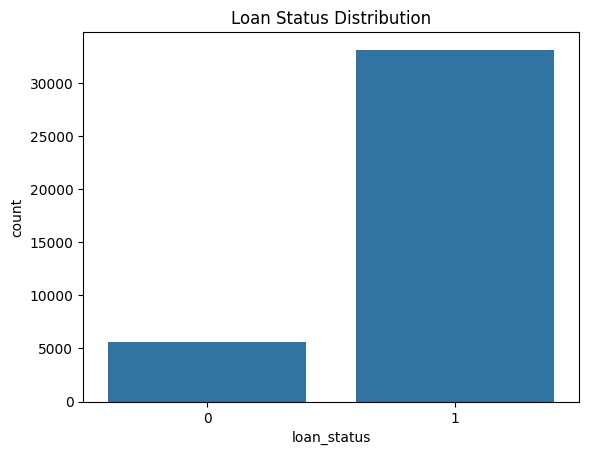

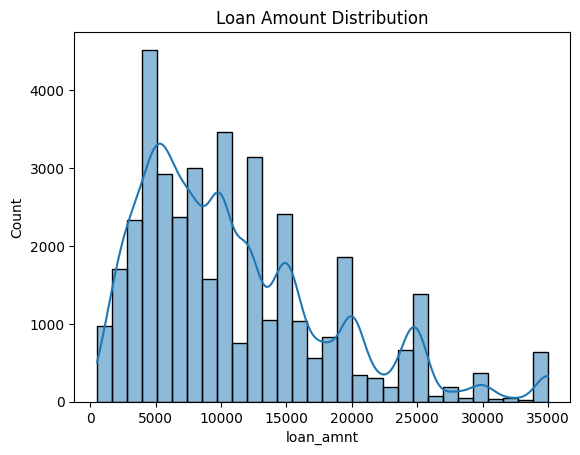

In [25]:
## Write Code here
## EDA: Univariate Analysis
sns.countplot(data=df, x='loan_status')
plt.title("Loan Status Distribution")
plt.show()

sns.histplot(df['loan_amnt'], kde=True, bins=30)
plt.title("Loan Amount Distribution")
plt.show()

**Observations**


*   Document your observations here



#### Bivariate Analysis

For the bivariate analysis, you can perform multiple analysis such as follows:

- How the default rate varies across the different variables
- Correlation Matrix
- etc.

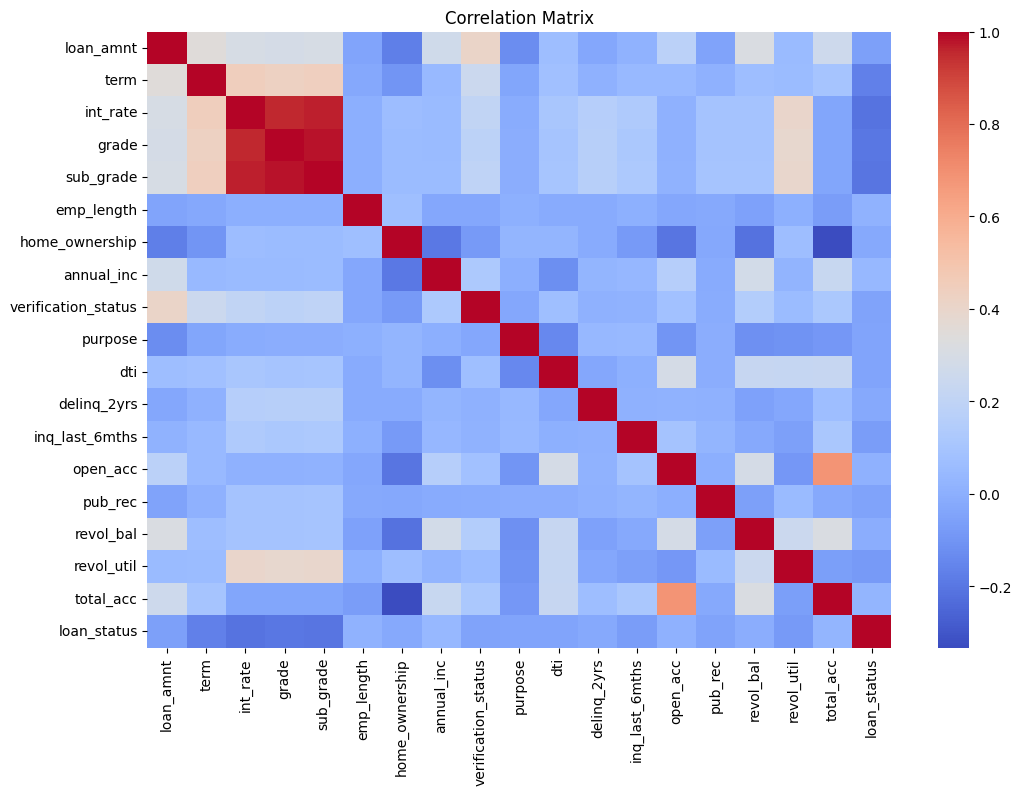

In [26]:
## Write Code here
## Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [27]:
## Write Code here
## Target variable (loan_status) and features
X = df.drop('loan_status', axis=1)
y = df['loan_status']

#### Pre-ML Data Pre-Processing

Before building the machine learning model, we shall perform
- encoding on all the categorical variables
- handle class imbalance
- train-test split
- scaling

##### Encoding variables

In [23]:
## Write the code
## Convert categorical columns to numeric using Label Encoding
categorical_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [29]:
## Write Code here
## Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
print("\nTrain-Test Split Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Train-Test Split Shapes:
X_train: (53017, 18) y_train: (53017,)
X_test: (13255, 18) y_test: (13255,)


In [ ]:
# Write code here

In [ ]:
# Write code here

**Handling Class Imbalance**

Suggestion - Perform SMOTE here

In [31]:
from imblearn.over_sampling import SMOTE


In [32]:
## Write Code here
## Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("Class Distribution After SMOTE:")
print(y_resampled.value_counts())

Class Distribution After SMOTE:
loan_status
1    33136
0    33136
Name: count, dtype: int64


In [ ]:
## Write code

In [ ]:
## Write code


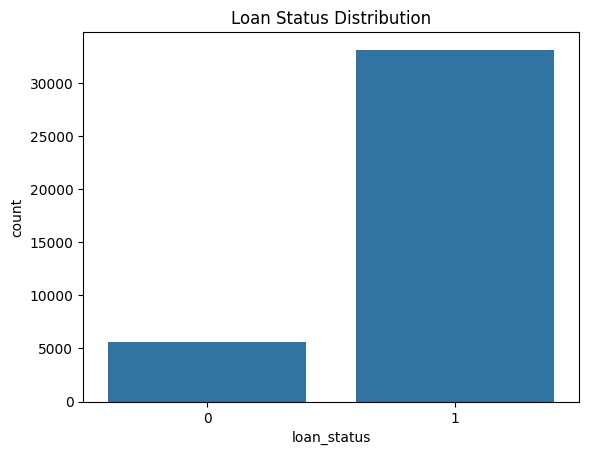

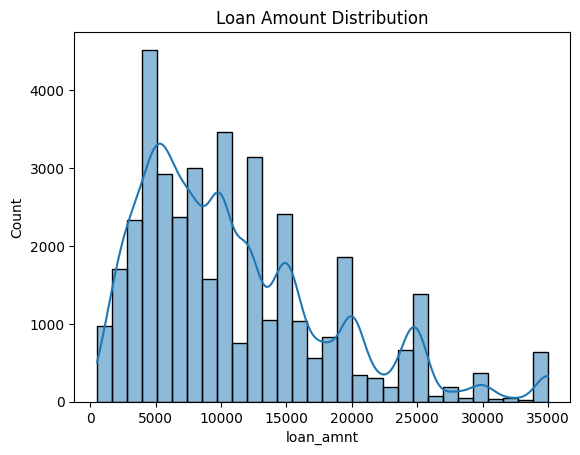

In [33]:
## Check the distribution of class in the newly resampled data
sns.countplot(data=df, x='loan_status')
plt.title("Loan Status Distribution")
plt.show()

sns.histplot(df['loan_amnt'], kde=True, bins=30)
plt.title("Loan Amount Distribution")
plt.show()


**Train-test split**

Now that we have handled class imbalance, let's perform the train-test split. We have to do a few additional imports

In [ ]:
# Splitting our dataset between training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = ## Write code here

Train-Test Split Shapes:
X_train: (31016, 18), y_train: (31016,)
X_test: (7754, 18), y_test: (7754,)

Class Distribution in Training Data:
loan_status
1    26555
0     4461
Name: count, dtype: int64

Class Distribution in Testing Data:
loan_status
1    6581
0    1173
Name: count, dtype: int64


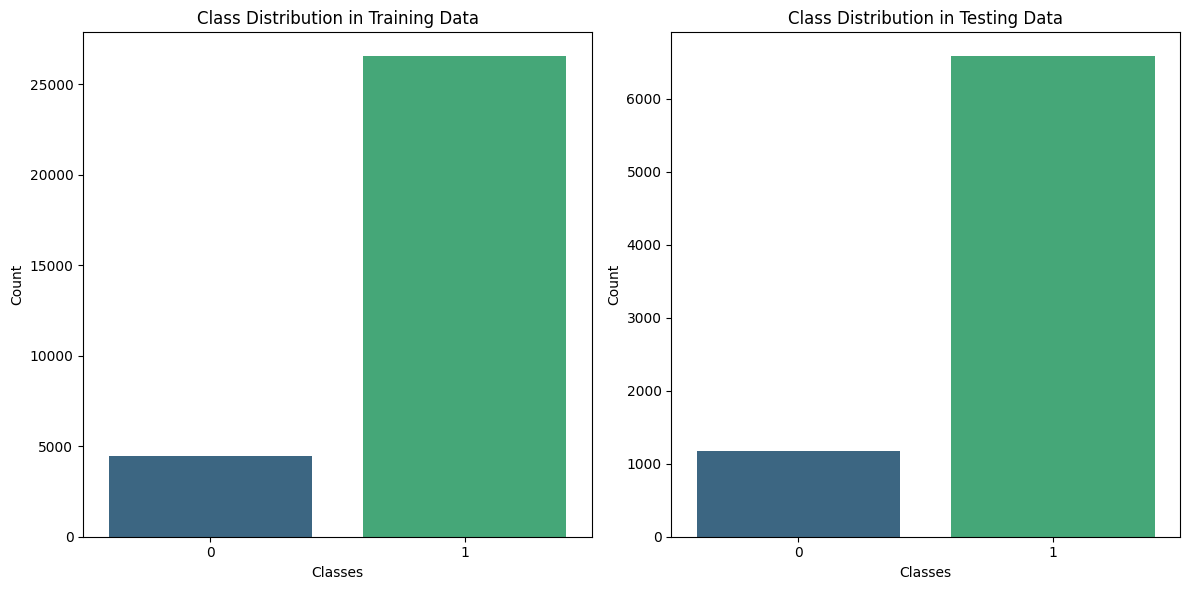


Training Data Statistics:
          loan_amnt          term      int_rate         grade     sub_grade  \
count  31016.000000  31016.000000  31016.000000  31016.000000  31016.000000   
mean   11038.605075      0.251096    124.810162      1.562645      9.871131   
std     7336.511671      0.433651     92.128098      1.382746      6.779182   
min      500.000000      0.000000      0.000000      0.000000      0.000000   
25%     5268.750000      0.000000     40.000000      0.000000      4.000000   
50%     9600.000000      0.000000    110.000000      1.000000      9.000000   
75%    15000.000000      1.000000    191.000000      2.000000     14.000000   
max    35000.000000      1.000000    370.000000      6.000000     34.000000   

         emp_length  home_ownership    annual_inc  verification_status  \
count  31016.000000    31016.000000  3.101600e+04         31016.000000   
mean       3.951122        2.152986  6.874167e+04             0.885092   
std        3.222022        1.932365  6.

In [34]:
## Check the samples
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the splits
print("Train-Test Split Shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Check for class distribution in training and testing datasets
print("\nClass Distribution in Training Data:")
print(y_train.value_counts())

print("\nClass Distribution in Testing Data:")
print(y_test.value_counts())

# Visualize class distributions (optional, for classification problems)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette="viridis")
plt.title("Class Distribution in Training Data")
plt.xlabel("Classes")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.countplot(x=y_test, palette="viridis")
plt.title("Class Distribution in Testing Data")
plt.xlabel("Classes")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Check basic statistics of numerical features in training and testing datasets
print("\nTraining Data Statistics:")
print(X_train.describe())

print("\nTesting Data Statistics:")
print(X_test.describe())



**Scaling**

In [35]:
from sklearn.preprocessing import MinMaxScaler
# Write code for MinMax Scaler
# Scale the data using MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Model Building and Model Evaluation

- Your task is to build at least 3 models and evaluate their performance
- Start with a baseline model such as logistic regression
- Build additional models like decision trees, random forests, XGboost, etc.
- Make sure you're checking for overfitting and underfitting
- Use cross-validation and hyperparamater tuning to fit the best models
- Evaluate each of the model using metrics such as accuracy, precision, recall, ROC-AUC score, etc.
- Select the best possible model that you will be using for classfication

Let's start off with the simplest model - Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Model 1: Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

In [37]:
## Build the model
## Check its evaluation metrics

print("\nLogistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]))



Logistic Regression Performance:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      1173
           1       0.85      1.00      0.92      6581

    accuracy                           0.85      7754
   macro avg       0.92      0.50      0.46      7754
weighted avg       0.87      0.85      0.78      7754

Accuracy: 0.8489811710085118
ROC AUC Score: 0.708446504332592


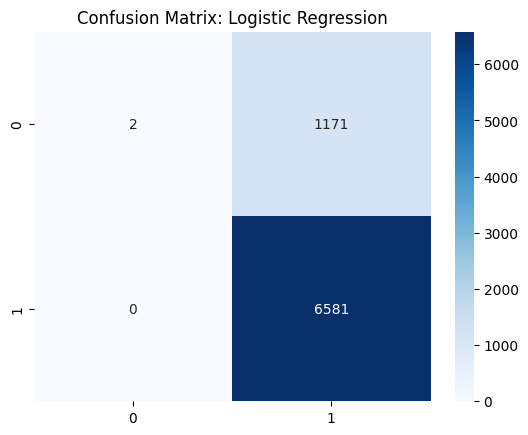

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Plot the Confusion Matrix
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression")
plt.show()


In [39]:
# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Performance:")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.33      0.08      0.13      1173
           1       0.86      0.97      0.91      6581

    accuracy                           0.84      7754
   macro avg       0.59      0.53      0.52      7754
weighted avg       0.78      0.84      0.79      7754

Accuracy: 0.8355687387155016


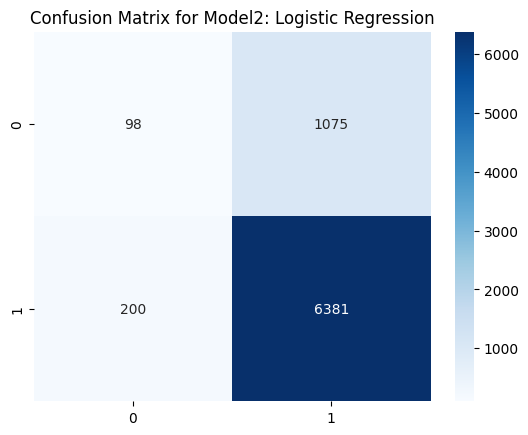

In [42]:
# Confusion Matrix for Model2 : Decision Tree
dt_cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(dt_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Model2: Logistic Regression")
plt.show()

In [41]:
# Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Performance:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))


Random Forest Performance:
              precision    recall  f1-score   support

           0       0.41      0.01      0.03      1173
           1       0.85      1.00      0.92      6581

    accuracy                           0.85      7754
   macro avg       0.63      0.51      0.47      7754
weighted avg       0.78      0.85      0.78      7754

Accuracy: 0.8478204797523858
ROC AUC Score: 0.6965349368541772


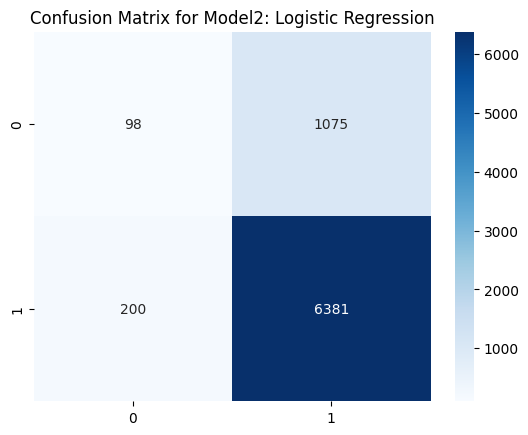

In [43]:
# Confusion Matrix for Model3 : Random Forest
rf_cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Model2: Logistic Regression")
plt.show()

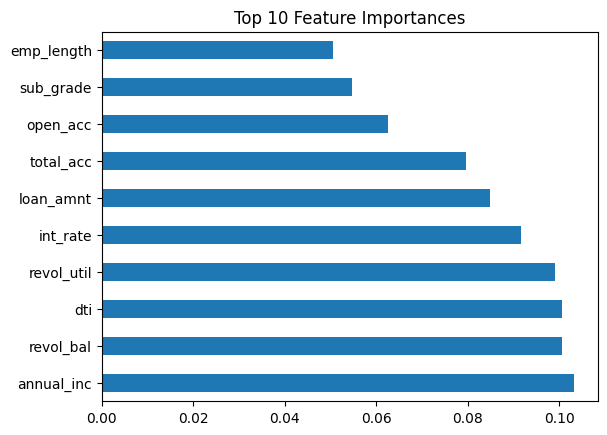

In [44]:
# Feature Importance (Random Forest)
feature_importances = pd.Series(rf.feature_importances_, index=df.drop('loan_status', axis=1).columns)
feature_importances.nlargest(10).plot(kind='barh', title='Top 10 Feature Importances')
plt.show()

In [45]:
from sklearn.metrics import classification_report
## Plot the classification report

Observations

- Document your observations

Next go ahead and build a decision tree and other models using the similar steps as above

Note
- You can build additional models as well
- Make sure you're performing the necessary steps to evaluate the model

Ensure that the following is done:

- The accuracy/precision/recall of the best model is at least between 80%
- All the necessary hyperparameter tuning, and regularization techniques (if needed) have been applied
- There's no overfitting

## Summary

Good work completing all the steps till now!
Now, go ahead and summarize your entire work and findings below:

-

-

-

---

### **Some Python libraries that are worth exploring for similar projects**
  - **tqdm**: A Python library used to create progress bars for iterables. It provides visual feedback on the progress of long-running operations, making it easier to track the execution time and estimate the remaining time.
  - **Low-code learning libraries** Use lazypredict or PyCaret to compare the performance of multiple Machine Learning models simultaneously. *The best part is that you only need to write fewer than 10 lines of code.*
  - **Explainable AI**: Understand model decisions through techniques like LIME or SHAP.